# Single Layer Perceptron (SLP) — Klasifikasi Iris (Setosa vs Versicolor)

Notebook ini mereplikasi perhitungan manual pada spreadsheet **PMM-TemplateSLP** ke dalam Python.

**Struktur perhitungan mengikuti spreadsheet:**
- `z = bias + (w1*x1 + w2*x2 + w3*x3 + w4*x4)`  → *dot product*
- `output = sigmoid(z)`
- `prediksi = 1 jika output >= 0.5, else 0`
- `error (per sampel) = (target - output)^2`
- `delta = 2*(output - target) * output * (1 - output)`  → gradien error terhadap `z`
- update bobot: `w = w - learning_rate * delta * x` , `bias = bias - learning_rate * delta`

Data: 100 baris (50 Setosa = kelas 0, 50 Versicolor = kelas 1). **10 data terakhir dari masing-masing kelas** dijadikan data *validation/testing*, sisanya (80 data) menjadi data *training* — persis seperti pada tab `Data`/`SLP` di spreadsheet.


## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## 2. Load Data

Data dibaca dari file **`iris_data.csv`** (harus berada di folder yang sama dengan notebook ini).
File ini berisi 100 baris data (50 Setosa = kelas 0, 50 Versicolor = kelas 1) dengan kolom
`X1, X2, X3, X4, TARGET` — persis seperti pada tab `Data` di spreadsheet.

> Ingin memakai data dari spreadsheet aslinya? Tinggal timpa file `iris_data.csv` dengan hasil
> ekspor sheet **Data** milikmu (pastikan nama kolomnya tetap `X1,X2,X3,X4,TARGET`), lalu jalankan
> ulang seluruh notebook. Tidak perlu mengubah kode apa pun.


In [2]:
CSV_PATH = "iris_data.csv"  # ganti path ini jika file csv berada di lokasi lain

def load_data(csv_path=CSV_PATH):
    """Load 100 data Iris (Setosa=0, Versicolor=1) dari file CSV, lalu split menjadi
    train (80 data) & validation/testing (20 data): 10 data TERAKHIR
    dari masing-masing kelas dijadikan data validation.
    """
    df = pd.read_csv(csv_path)   # kolom: X1, X2, X3, X4, TARGET

    # index kelas 0 (Setosa) & kelas 1 (Versicolor)
    setosa_idx     = df.index[df["TARGET"] == 0]
    versicolor_idx = df.index[df["TARGET"] == 1]

    valid_idx = list(setosa_idx[-10:]) + list(versicolor_idx[-10:])   # 10 terakhir tiap kelas
    train_idx = [i for i in df.index if i not in valid_idx]           # sisanya (80 data)

    df_train = df.loc[train_idx].reset_index(drop=True)
    df_valid = df.loc[valid_idx].reset_index(drop=True)

    return df, df_train, df_valid


df_all, df_train, df_valid = load_data()

print(f"Total data     : {len(df_all)}")
print(f"Data training  : {len(df_train)}")
print(f"Data validation: {len(df_valid)}")
df_all.head()


Total data     : 100
Data training  : 80
Data validation: 20


,X1,X2,X3,X4,TARGET
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Fungsi-fungsi Utama SLP

Setiap fungsi mengikuti rumus pada kolom spreadsheet:

| Fungsi Python | Kolom di spreadsheet |
|---|---|
| `weight_initialization` | `Bobot bias` baris pertama (bias, teta1..teta4 = 0.5) |
| `dot_product` | kolom `z/h?` |
| `sigmoid_function` | kolom `Sigmoid g(z)` |
| `error_function` | kolom `error` |
| `weight_update` | perubahan `Bobot bias` antar baris |
| `accuracy_calculation` | kolom `Acc Trai` / `Acc Valid` di REKAP PER EPOCH |


In [3]:
def weight_initialization(n_features, init_value=0.5):
    """Inisialisasi bias & bobot. Di spreadsheet semua diawali 0.5."""
    bias = init_value
    weights = np.full(n_features, init_value, dtype=float)
    return bias, weights


def dot_product(bias, weights, x):
    """z / h = bias + (w1*x1 + w2*x2 + w3*x3 + w4*x4)"""
    return bias + np.dot(weights, x)


def sigmoid_function(z):
    """g(z) = 1 / (1 + e^-z)"""
    return 1.0 / (1.0 + np.exp(-z))


def error_function(target, output):
    """error = (target - output)^2  (sama seperti kolom 'error' di spreadsheet)"""
    return (target - output) ** 2


def error_gradient(target, output):
    """delta = dE/dz = 2*(output - target) * output * (1 - output)
    Ini adalah turunan dari error_function terhadap z, dipakai untuk weight_update.
    (Nilai ini identik dengan kolom dbias/dteta1..4 pada spreadsheet.)
    """
    return 2 * (output - target) * output * (1 - output)


def weight_update(bias, weights, x, delta, learning_rate):
    """w_baru = w_lama - learning_rate * delta * x
       bias_baru = bias_lama - learning_rate * delta
    """
    new_weights = weights - learning_rate * delta * x
    new_bias = bias - learning_rate * delta
    return new_bias, new_weights


def predict(output, threshold=0.5):
    """Prediksi = 1 jika output >= 0.5, else 0"""
    return 1 if output >= threshold else 0


def accuracy_calculation(bias, weights, X, y):
    """Hitung akurasi & rata-rata error (loss) sebuah dataset dengan bobot saat ini."""
    preds, errors = [], []
    for xi, ti in zip(X, y):
        z = dot_product(bias, weights, xi)
        o = sigmoid_function(z)
        preds.append(predict(o))
        errors.append(error_function(ti, o))
    preds = np.array(preds)
    acc = np.mean(preds == np.array(y))
    loss = np.mean(errors)
    return loss, acc


## 4. Proses Training (Stochastic Gradient Descent, per-sampel)

Sama seperti spreadsheet: bobot **diperbarui setiap satu baris data training** (bukan menunggu
satu epoch penuh). *Loss Train* & *Acc Train* pada satu epoch dihitung dari rata-rata error/prediksi
setiap sampel **sebelum** bobot diperbarui pada sampel itu (perilaku "online learning").
*Loss Valid* & *Acc Valid* dihitung dengan *forward pass* biasa di akhir epoch (data validasi tidak
dipakai untuk update bobot).


In [4]:
def train_slp(df_train, df_valid, learning_rate=0.1, epochs=5, init_value=0.5):
    feature_cols = ["X1", "X2", "X3", "X4"]
    X_train, y_train = df_train[feature_cols].values, df_train["TARGET"].values
    X_valid, y_valid = df_valid[feature_cols].values, df_valid["TARGET"].values

    bias, weights = weight_initialization(n_features=X_train.shape[1], init_value=init_value)

    history = {"epoch": [], "loss_train": [], "loss_valid": [], "acc_train": [], "acc_valid": []}

    for epoch in range(1, epochs + 1):
        epoch_errors, epoch_preds = [], []

        for xi, ti in zip(X_train, y_train):
            z = dot_product(bias, weights, xi)
            o = sigmoid_function(z)

            epoch_errors.append(error_function(ti, o))
            epoch_preds.append(predict(o))

            delta = error_gradient(ti, o)
            bias, weights = weight_update(bias, weights, xi, delta, learning_rate)

        loss_train = np.mean(epoch_errors)
        acc_train = np.mean(np.array(epoch_preds) == y_train)

        loss_valid, acc_valid = accuracy_calculation(bias, weights, X_valid, y_valid)

        history["epoch"].append(epoch)
        history["loss_train"].append(loss_train)
        history["loss_valid"].append(loss_valid)
        history["acc_train"].append(acc_train)
        history["acc_valid"].append(acc_valid)

    return bias, weights, pd.DataFrame(history)


LEARNING_RATE = 0.1
EPOCHS = 5

final_bias, final_weights, history_df = train_slp(
    df_train, df_valid, learning_rate=LEARNING_RATE, epochs=EPOCHS, init_value=0.5
)

print(f"Bias akhir   : {final_bias:.6f}")
print(f"Bobot akhir  : {final_weights}")


Bias akhir   : 0.258572
Bobot akhir  : [-0.23888778 -0.42193939  1.1221906   0.82101673]


## 5. Rekap Per Epoch (setara tabel `REKAP PER EPOCH` di spreadsheet)

In [5]:
rekap = history_df.rename(columns={
    "epoch": "Epoch",
    "loss_train": "Loss Train",
    "loss_valid": "Loss Valid",
    "acc_train": "Acc Train",
    "acc_valid": "Acc Valid",
})
rekap


,Epoch,Loss Train,Loss Valid,Acc Train,Acc Valid
0,1,0.450046,0.328014,0.5250,0.50
1,2,0.037215,0.246373,0.9500,0.50
2,3,0.024224,0.175153,0.9750,0.50
3,4,0.017254,0.118946,0.9750,0.85
4,5,0.012664,0.081341,0.9875,1.00


## 6. Grafik Loss Train vs Loss Valid

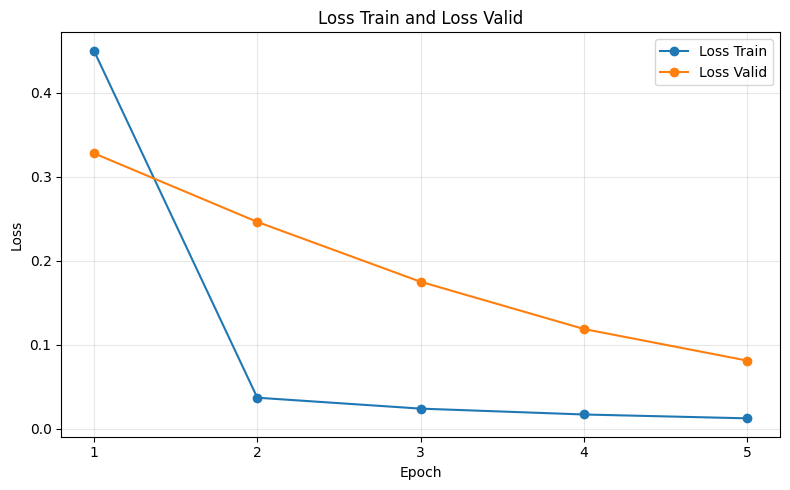

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["loss_train"], marker="o", label="Loss Train")
plt.plot(history_df["epoch"], history_df["loss_valid"], marker="o", label="Loss Valid")
plt.title("Loss Train and Loss Valid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Grafik Acc Train vs Acc Valid

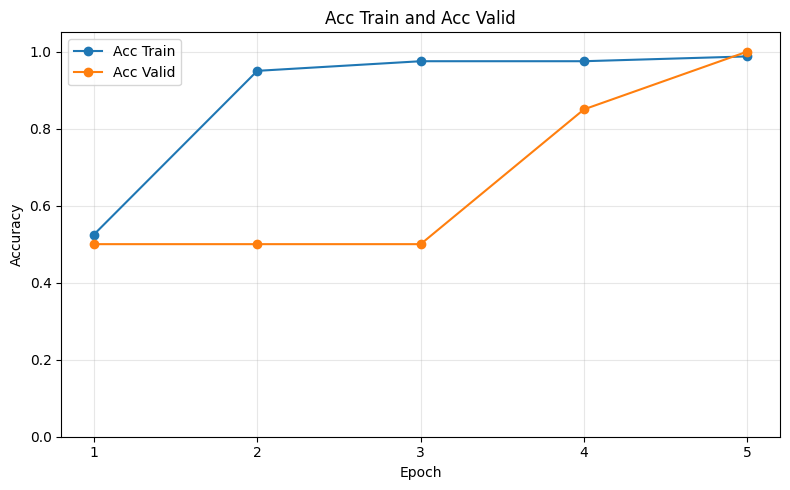

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["acc_train"], marker="o", label="Acc Train")
plt.plot(history_df["epoch"], history_df["acc_valid"], marker="o", label="Acc Valid")
plt.title("Acc Train and Acc Valid")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(history_df["epoch"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
